In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
from predictor import predict_fn
from perturbation import perturb_text
from feature_extraction.features_script import stability_score

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to C:\Users\DELL
[nltk_data]     3530\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1312.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import importlib
import perturbation

importlib.reload(perturbation)

<module 'perturbation' from 'c:\\AI_plag_detection_sys\\train\\perturbation.py'>

In [7]:
df = pd.read_csv("../dataset/processed_data/final_cleaned_ds.csv")

df_sample = df.sample(200, random_state=42).reset_index(drop=True)

In [10]:
df.columns

Index(['full_text', 'label', 'word_count'], dtype='str')

In [11]:
df_sample.columns

Index(['full_text', 'label', 'word_count'], dtype='str')

In [8]:
stability_scores = []

for text in df_sample["full_text"]:
    s = stability_score(predict_fn, text, perturb_text)
    stability_scores.append(s)

df_sample["stability"] = stability_scores

df_sample.to_csv("features_with_stability.csv", index=False)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  w

In [9]:
df_sample["stability"].describe()

count    2.000000e+02
mean     4.117492e-03
std      1.824143e-02
min      0.000000e+00
25%      5.800536e-08
50%      4.246993e-07
75%      1.560041e-05
max      1.225056e-01
Name: stability, dtype: float64

In [10]:
text = df_sample["full_text"][0]
variations = perturb_text(text)

for v in variations:
    print(predict_fn(v))

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


0.028671699


c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


0.029874876
0.033173256


c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
df_sample.groupby("label")["stability"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,103.0,0.000772,0.007806,0.0,2.669995e-08,1.086976e-07,4.946244e-07,0.079222
1,97.0,0.007670,0.024500,0.0,3.816305e-07,3.971722e-06,7.496546e-04,0.122506


In [11]:
text = df_sample["full_text"][0]
variations = perturb_text(text)

for v in variations:
    print("TEXT:", v)
    print("PRED:", predict_fn(v))
    print()

TEXT: really very thinks of the first idea that springs a mind would be a car. A is used almost daily for people. It helps us get to A to point B really shine. However, complications very from the extremely of cars. The very of limiting car usage includes reduction in promote very quite and cut quite traffic. Pollution quite very a growing quite as the world to really The greenhouse gases by machines, such as cars, have been proven detrimental to the In car-dense citites, quite a really of smoke and has become a nuisance as it covers cities. In extreme cases,it makes the air breathe toxic! According to Source 1, " Passenger cars extremely responsible for 12 of greenhouse gas emission in Europe... and up to 50 in some car-intensive in the United extremely To limits to usage very then, therefore, reduce the emission of greenhouse gases in the atmosphere and extremely conditions not for the world, make the over-all city enjoyable to live really In order to very pollution and clear the Par

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


PRED: 0.033173256

TEXT: one quite of transportation, the first that springs a persons mind would really a A really is used almost daily for many people. It helps get to point A to point quite or shine. However, very from the use (or of cars. The advantages of limiting really includes reduction in pollution, promote public transport, and quite off traffic. has become a growing problem as the world continues to industrialize. The greenhouse gases emitted by machines, such as very have been proven detrimental to the enviornment. In car-dense citites, smog, a mixture of smoke and fog, extremely a nuisance as it covers cities. In extreme cases,it quite the air quite extremely extremely to Source quite really really are extremely for 12 percent of greenhouse emission in Europe... and up to quite percent in some car-intensive areas in the United To to very usage would therefore, reduce the emission of greenhouse gases in the atmosphere and clear up conditions not only for the world, but real

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


PRED: 0.034937683

TEXT: one thinks of the first that springs very a persons quite quite a extremely A car is used almost daily for many very It helps us to point A to very B rain or shine. complications really very the use extremely overuse) of The quite of limiting car includes quite in pollution, very really transport, and cut off traffic. Pollution has become a growing problem as the world continues to extremely The really gases emitted by machines, such as cars, very been proven detrimental to the enviornment. In extremely citites, smog, a mixture of smoke and fog, become a nuisance as it really In extreme very the air citizens very toxic! According to 1, " Passenger cars are very for very quite of greenhouse really in and really to 50 in areas in the very States.". To establish limits to car very would extremely therefore, reduce the emission of greenhouse gases in the atmosphere and up conditions not quite for the extremely but extremely the over-all city more to live in. In ord

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
df_sample.to_csv("features_with_stability.csv", index=False)

In [14]:
df_sample[["full_text", "label", "stability"]].to_csv(
    "stability_only.csv", index=False
)

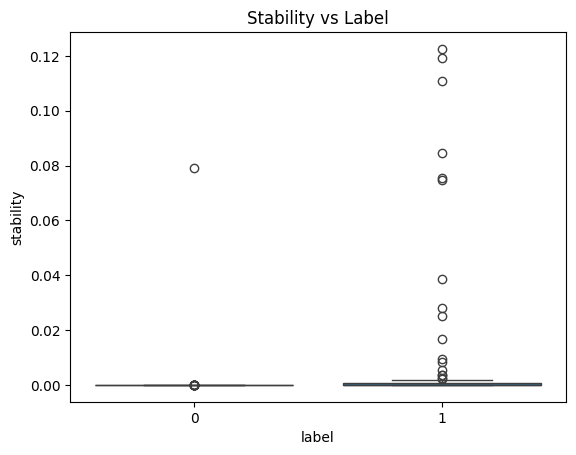

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="label", y="stability", data=df_sample)
plt.title("Stability vs Label")
plt.show()